In [1]:
import numpy as np 
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv('Social_Network_Ads.csv',usecols=[2,3,4])

In [5]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [10]:
x = df.drop(columns='Purchased')
y = df.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# PDF & QQPLOT Before Mathematical_Transformer

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_4156\100400416.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


Text(0.5, 1.0, 'QQPlot Age')

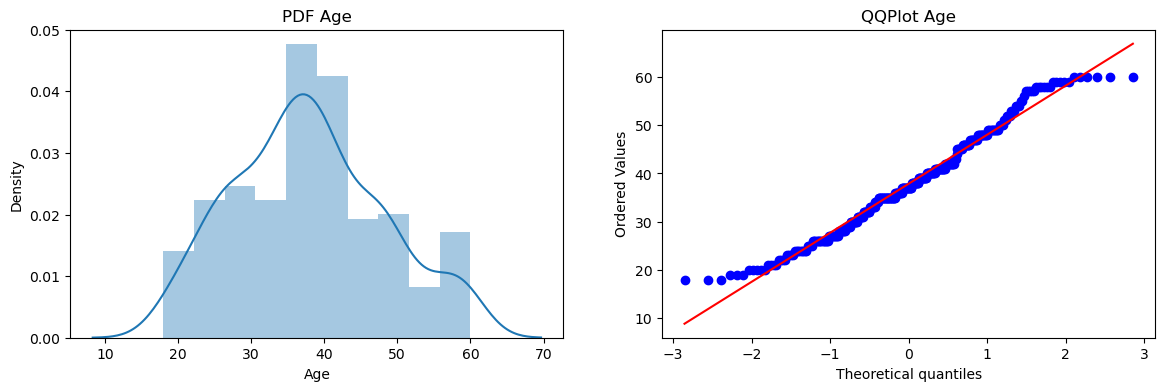

In [11]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('PDF Age')

plt.subplot(122)
stats.probplot(x_train['Age'], dist="norm" , plot=plt)
plt.title('QQPlot Age')

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_4156\3095917659.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['EstimatedSalary'])


Text(0.5, 1.0, 'QQPlot Age')

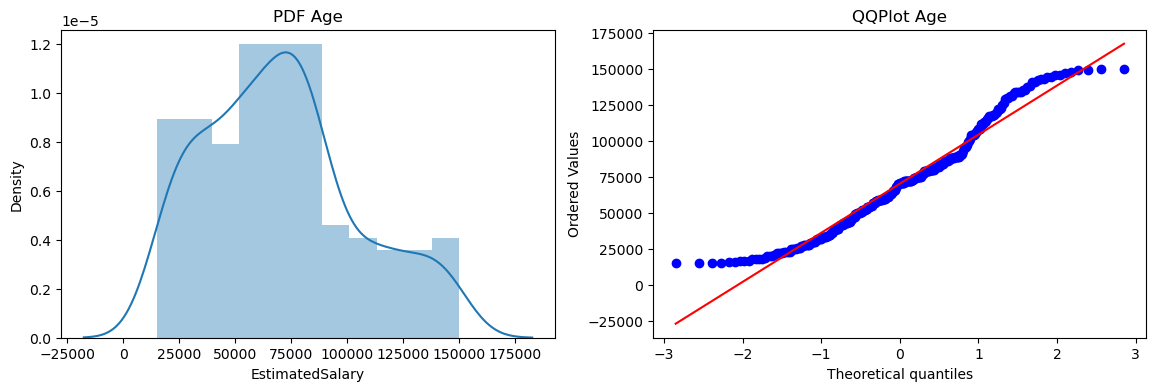

In [12]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.distplot(x_train['EstimatedSalary'])
plt.title('PDF Age')

plt.subplot(122)
stats.probplot(x_train['EstimatedSalary'], dist="norm" , plot=plt)
plt.title('QQPlot Age')

# Mathematical_Transformer

In [23]:
trf = FunctionTransformer(func=np.sqrt)

x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.fit_transform(x_test)

Text(0.5, 1.0, 'QQPlot After EstimatedSalary')

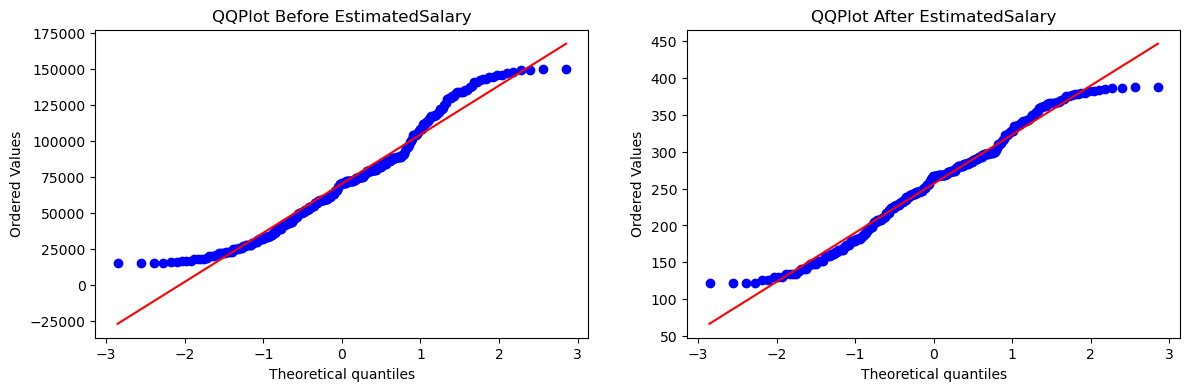

In [34]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['EstimatedSalary'], dist="norm" , plot=plt)
plt.title('QQPlot Before EstimatedSalary')

plt.subplot(122)
stats.probplot(x_train_transformed['EstimatedSalary'], dist="norm" , plot=plt)
plt.title('QQPlot After EstimatedSalary')

Text(0.5, 1.0, 'QQPlot After Age')

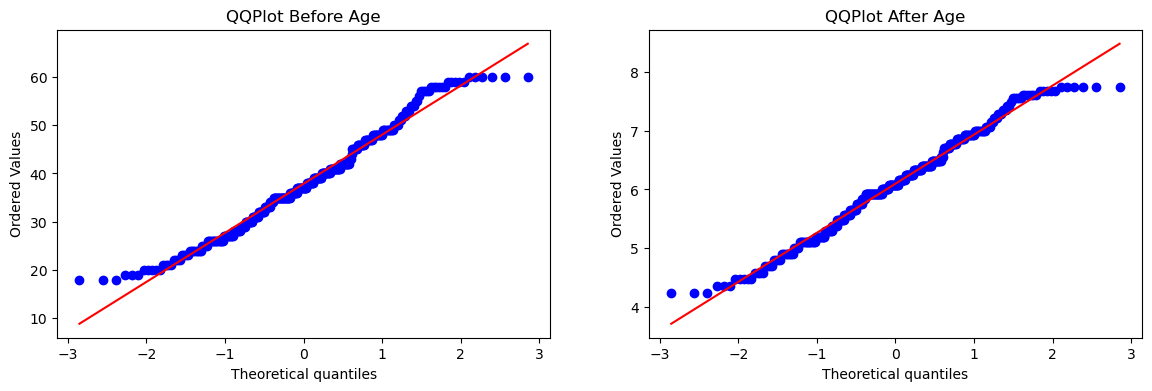

In [33]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Age'], dist="norm" , plot=plt)
plt.title('QQPlot Before Age')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist="norm" , plot=plt)
plt.title('QQPlot After Age')

# Model Without Function_Transformer

In [41]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred = clf.predict(x_test)
y_pred2 = clf2.predict(x_test)

print("accuracy Lr",accuracy_score(y_test,y_pred))
print("accuracy Dt",accuracy_score(y_test,y_pred2))

accuracy Lr 0.8875
accuracy Dt 0.8375


In [42]:
print("Accuracy Lr",np.mean(cross_val_score(clf, x, y, scoring="accuracy", cv=10)))
print("Accuracy Dt",np.mean(cross_val_score(clf2, x, y, scoring="accuracy", cv=10)))

Accuracy Lr 0.8225
Accuracy Dt 0.8324999999999999


# model After Mathematical_Transformer

In [43]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print("accuracy Lr",accuracy_score(y_test,y_pred))
print("accuracy Dt",accuracy_score(y_test,y_pred2))

accuracy Lr 0.875
accuracy Dt 0.85


In [45]:
x_transformed = trf.fit_transform(x)

print("Accuracy Lr",np.mean(cross_val_score(clf, x_transformed, y, scoring="accuracy", cv=10)))
print("Accuracy Dt",np.mean(cross_val_score(clf2, x_transformed, y, scoring="accuracy", cv=10)))

Accuracy Lr 0.8125
Accuracy Dt 0.835
